## Лабораторная работа №1 | Вариант 5

Выполнил: 

### 1. Numpy

In [2]:
import numpy as np

1. Создайте единичную матрицу размером 3х3

In [3]:
m = np.eye(3)
m

array([[1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.]])

2. Создайте кастомный dtype который описывает цвет состоящий из 4х unsigned bytes(RGBA пиксель)

In [4]:
rgba_dtype = np.dtype([("r", np.uint8),
                       ("g", np.uint8),
                       ("b", np.uint8),
                       ("a", np.uint8)])

3. Как игнорировать все numpy warnings(не рекомендуем к использованию)?

In [5]:
np.seterr(all="ignore")

{'divide': 'warn', 'over': 'warn', 'under': 'ignore', 'invalid': 'warn'}

4. Создайте случайный вектор размера 10 и отсортируйте его

In [6]:
v = np.random.rand(10)
sorted_v = np.sort(v)
sorted_v

array([0.02485409, 0.03376434, 0.24378189, 0.29178555, 0.41254405,
       0.46150374, 0.58933803, 0.66430434, 0.77843337, 0.82420657])

5. Создайте read-only массив(неизменяемый)

In [7]:
arr = np.arange(10)
arr.flags.writeable = False
#arr[0] = 1

6. Рассмотрим случайную матрицу размером 10х2, представляющую декартовы координаты, преобразуем их в полярные координаты

In [8]:
matrix = np.random.randn(10, 2)

x = matrix[:, 0]
y = matrix[:, 1]

r = np.sqrt(x ** 2 + y ** 2)
theta = np.arctan2(y, x)
polar = np.column_stack((r, theta))

polar

array([[ 2.14442494,  2.59042936],
       [ 2.53526169, -0.4882773 ],
       [ 1.78995059, -0.51292246],
       [ 1.51208279,  1.40204757],
       [ 2.41454551, -1.92652479],
       [ 0.32331489,  0.59878145],
       [ 1.40925477, -3.05672196],
       [ 0.68510272,  2.6049914 ],
       [ 1.60190411,  0.99460991],
       [ 1.20687618,  2.50088251]])

7. Создайте структурированный массив с координатами x и y, охватывающий область [0,1]x[0,1]

In [9]:
Z = np.zeros((10, 10), [("x", float), ("y", float)])
Z["x"], Z["y"] = np.meshgrid(np.linspace(0, 1, 10), np.linspace(0, 1, 10), indexing="xy")
Z

array([[(0.        , 0.        ), (0.11111111, 0.        ),
        (0.22222222, 0.        ), (0.33333333, 0.        ),
        (0.44444444, 0.        ), (0.55555556, 0.        ),
        (0.66666667, 0.        ), (0.77777778, 0.        ),
        (0.88888889, 0.        ), (1.        , 0.        )],
       [(0.        , 0.11111111), (0.11111111, 0.11111111),
        (0.22222222, 0.11111111), (0.33333333, 0.11111111),
        (0.44444444, 0.11111111), (0.55555556, 0.11111111),
        (0.66666667, 0.11111111), (0.77777778, 0.11111111),
        (0.88888889, 0.11111111), (1.        , 0.11111111)],
       [(0.        , 0.22222222), (0.11111111, 0.22222222),
        (0.22222222, 0.22222222), (0.33333333, 0.22222222),
        (0.44444444, 0.22222222), (0.55555556, 0.22222222),
        (0.66666667, 0.22222222), (0.77777778, 0.22222222),
        (0.88888889, 0.22222222), (1.        , 0.22222222)],
       [(0.        , 0.33333333), (0.11111111, 0.33333333),
        (0.22222222, 0.33333333), (0.

8. Учитывая два массива X и Y, постройте матрицу Коши $C$ ($C_{ij} =\frac{1}{x_i - y_j}$)

In [10]:
x = np.random.normal(size=(5))
y = np.random.normal(size=(5))
C = np.fromfunction(lambda i, j: 1 / (x[i.astype(int)] - y[j.astype(int)]), (len(x), len(y)))
C


array([[-0.3329593 , -0.38334368, -0.26435948, -0.3112186 , -0.49274507],
       [-0.36119844, -0.42126257, -0.28185535, -0.33575448, -0.55721539],
       [-1.0483982 , -1.78861695, -0.57696946, -0.85937116, 49.78331193],
       [-0.51501236, -0.64643075, -0.36750399, -0.4647906 , -1.03329496],
       [-1.47211302, -3.51431072, -0.68556373, -1.12473138,  3.39411708]])

C9. Как конвертировать массив float(32 bit) к массиву целых чисел (integer 32 bit) in place?

In [11]:
a = np.array([1.5, 2.5, 3.5], dtype=np.float32)
print(a)
a_view = a.view(np.int32)
a_view[:] = a
a_view[0] = 0
print(a)

[1.5 2.5 3.5]
[0.e+00 3.e-45 4.e-45]


10. Как случайно заменить p элементов в 2D массиве?

In [12]:
a = np.arange(15)
val = 999
p = 5
np.put(a, np.random.choice(range(a.size), p, replace=False), val)
a

array([  0,   1, 999,   3, 999, 999,   6,   7,   8,   9, 999,  11, 999,
        13,  14])

### 2. Pandas

Найдите ответы на вопросы или выполните действия с предложенным датасетом 

Классический начальный набор данных - данные пассажиров титаника.

Файл: `data.csv`

```
PassangerId - уникальный номер пассажира
Survived - выжил человек или нет
Pclass - класс обслуживания
Name - имя человека, обращение к ней/нему
Sex - пол человека
Age - возраст на момент крушения
SibSp - количество братьев и сестер / супругов на борту "Титаника"
Parch - количество родителей / детей на борту "Титаника"
Ticket - номер билета
Fare - стоимость проезда для пассажиров
Cabin - каюта
Embarked - причал отбытия. C = Cherbourg Q = Queenstown S = Southampton
```

In [13]:
import pandas as pd

In [14]:
df = pd.read_csv("data.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


1. Узнайте сколько было на борту человек

In [49]:
total_people = df["PassengerId"].count()
print(f"{total_people} - было человек на борту")

891 - было человек на борту


2. Какой медианный и средний возраста пассажиров

In [47]:
print(f"Средний - {df["Age"].mean():.2f}")
print(f"Медианный - {df["Age"].median():.2f}")

Средний - 29.70
Медианный - 28.00


3. Посчитайте процент выживаемости детей(до 16 лет) и взрослых

In [17]:
df_with_age = df[df["Age"].notna()]
children = df_with_age[df_with_age["Age"] < 16]
adults = df_with_age[df_with_age["Age"] >= 16]
children_survival = children["Survived"].mean() * 100
adults_survival = adults["Survived"].mean() * 100
print(f"Выживаемость детей: {children_survival:.2f}%")
print(f"Выживаемость взрослых: {adults_survival:.2f}%")

Выживаемость детей: 59.04%
Выживаемость взрослых: 38.19%


4. Верна ли гипотеза, что женщины и дети сажались в шлюпки первыми и выживали больше?

In [52]:
df_age = df[df["Age"].notna()].copy()


def categorize(row):
    if row["Sex"] == "female" or row["Age"] < 16:
        return "Женщины и дети"
    else:
        return "Взрослые мужчины"


df_age["Category"] = df_age.apply(categorize, axis=1)
print("\nЖенщины/дети vs взрослые мужчины:")
survival_comparison = df_age.groupby("Category")["Survived"].mean() * 100
survival_comparison
women_children_rate = survival_comparison["Женщины и дети"]
adult_men_rate = survival_comparison["Взрослые мужчины"]
print(f"\nЖенщины и дети: {women_children_rate:.2f}%")
print(f"Взрослые мужчины: {adult_men_rate:.2f}%")
print(f"Разница: {women_children_rate - adult_men_rate:.1f} процентов")

if women_children_rate > adult_men_rate:
    print(f"\nЖенщины и дети выживали чаще на {women_children_rate - adult_men_rate:.1f}%")
    print("ВЫВОД: Гипотеза верна")
else:
    print(f"\nВзрослые мужчины выживали чаще на {adult_men_rate - women_children_rate:.1f}%")
    print("ВЫВОД: Гипотеза не верна")


Женщины/дети vs взрослые мужчины:

Женщины и дети: 72.43%
Взрослые мужчины: 17.43%
Разница: 55.0 процентов

Женщины и дети выживали чаще на 55.0%
ВЫВОД: Гипотеза верна


5. Зависит ли выживаемость от класса обслуживания?

In [56]:
survival_by_class = df.groupby("Pclass")["Survived"].mean() * 100
print("Выживаемость по классам:")
first_class = survival_by_class[1]
second_class = survival_by_class[2]
third_class = survival_by_class[3]

print(f"\n1 класс: {first_class:.2f}%")
print(f"2 класс: {second_class:.2f}%")
print(f"3 класс: {third_class:.2f}%")

if (first_class or second_class) > third_class:
    print(f"\nПассажиры 1-2 класса выживали чаще на {first_class - third_class:.2f}%")
    print("ВЫВОД: Класс обслуживания напрямую влиял")
    print("       на шансы выживания")

Выживаемость по классам:

1 класс: 62.96%
2 класс: 47.28%
3 класс: 24.24%

Пассажиры 1-2 класса выживали чаще на 38.73%
ВЫВОД: Класс обслуживания напрямую влиял
       на шансы выживания


6. Посчитайте средний возраст умерших женщин и мужчин

In [44]:
died = df[df["Survived"] == 0]
mean_age_of_deceased = died.groupby("Sex")["Age"].mean()
avg_woman = mean_age_of_deceased.get("female", 0)
avg_man = mean_age_of_deceased.get("male", 0)
print(f"Средний возраст мужчин - {avg_man:.2f}\nСредний возраст женщин - {avg_woman:.2f}")

Средний возраст мужчин - 31.62
Средний возраст женщин - 25.05


7. Различается ли процент выживаемости пассажиров с хотя бы одним родственником на борту и одиночек?

In [45]:

df["Has_Relatives"] = (df["SibSp"] > 0) | (df["Parch"] > 0)
df["Category"] = df["Has_Relatives"].apply(
    lambda x: "С родственниками" if x else "Одиночки")
df["Has_Relatives"] = (df["SibSp"] > 0) | (df["Parch"] > 0)
df["Category"] = df["Has_Relatives"].apply(
    lambda x: "С родственниками" if x else "Одиночки"
)
comparision = df.groupby("Category")["Survived"].mean() * 100
with_siblings = comparision["С родственниками"]
without_siblings = comparision["Одиночки"]

if with_siblings > without_siblings:
    print(f"\nПассажиры с родственниками выживали чаще на {with_siblings - without_siblings:.2f}%")
    print("ВЫВОД: Наличие родственников на борту")
    print("       повышало шансы на спасение.")
else:
    print(f"\nОдиночки выживали чаще на {without_siblings - with_siblings:.2f}%")
    print("ВЫВОД: Пассажиры без родственников")
    print("       имели преимущество в спасении.")


Пассажиры с родственниками выживали чаще на 20.21%
ВЫВОД: Наличие родственников на борту
       повышало шансы на спасение.


8. Различается ли средняя стоимость билета у умерших и выживших пассажиров?

In [42]:
mean_fare = df.groupby("Survived")["Fare"].mean()
died_fare = mean_fare[0]
survived_fare = mean_fare[1]

print(f"\nУмершие: ${died_fare:.2f}")
print(f"Выжившие: ${survived_fare:.2f}")
print(f"Разница: ${abs(survived_fare - died_fare):.2f}")


if survived_fare > died_fare:
    print(f"Выжившие пассажиры платили в среднем на ${survived_fare - died_fare:.2f} больше")
    print("ВЫВОД: Пассажиры с более дорогими билетами")
    print("       имели больше шансов на спасение.")
else:
    print(f"Погибшие пассажиры платили в среднем на ${died_fare - survived_fare:.2f} больше")
    print("ВЫВОД: Пассажиры с более дорогими билетами")
    print("       почему-то выживали хуже (необычно).")



Умершие: $22.12
Выжившие: $48.40
Разница: $26.28
Выжившие пассажиры платили в среднем на $26.28 больше
ВЫВОД: Пассажиры с более дорогими билетами
       имели больше шансов на спасение.


9. Выведите максимальный и минимальный возраст выживших пассажиров во 2 классе обслуживания

In [23]:
second_survived = df[(df["Pclass"] == 2) & (df["Survived"] == 1)]["Age"]
print(f"Максимальный {second_survived.max()}, минимальный {second_survived.min()}")

Максимальный 62.0, минимальный 0.67


10. Подтвердите или опровергните гипотезу: молодым мужчинам(от 18 лет) выжить легче, чем более взрослым

In [39]:
#пусть молодой до 30
mans = df[df["Sex"] == "male"].copy()
mans["Category"] = mans["Age"].apply(lambda x: "Молодые" if (x > 18 and x <= 30) else "Взрослые")
survived_mans = mans.groupby("Category")["Survived"].mean() * 100
young_rate = survived_mans.get("Молодые", 0)
adult_rate = survived_mans.get("Взрослые", 0)

if young_rate > adult_rate:
    print("ГИПОТЕЗА ПОДТВЕРЖДЕНА")
    print(f"\nМолодые мужчины (18-30 лет): {young_rate:.1f}%")
    print(f"Взрослые мужчины (30+ лет): {adult_rate:.1f}%")
    print(f"Разница: {young_rate - adult_rate:.1f}% в пользу молодых")
else:
    print("ГИПОТЕЗА ОПРОВЕРГНУТА")
    print(f"\nМолодые мужчины (18-30 лет): {young_rate:.1f}%")
    print(f"Взрослые мужчины (30+ лет): {adult_rate:.1f}%")
    print(f"Разница: {adult_rate - young_rate:.1f}% в пользу взрослых")

ГИПОТЕЗА ОПРОВЕРГНУТА

Молодые мужчины (18-30 лет): 15.6%
Взрослые мужчины (30+ лет): 20.4%
Разница: 4.8% в пользу взрослых


### 3. Визуализация

Используя библиотеки matplotlib/sns/plotly/pandas и набор данных представленный ранее визуализируйте

1. Постройте гистограмму распределения возростов пассажиров

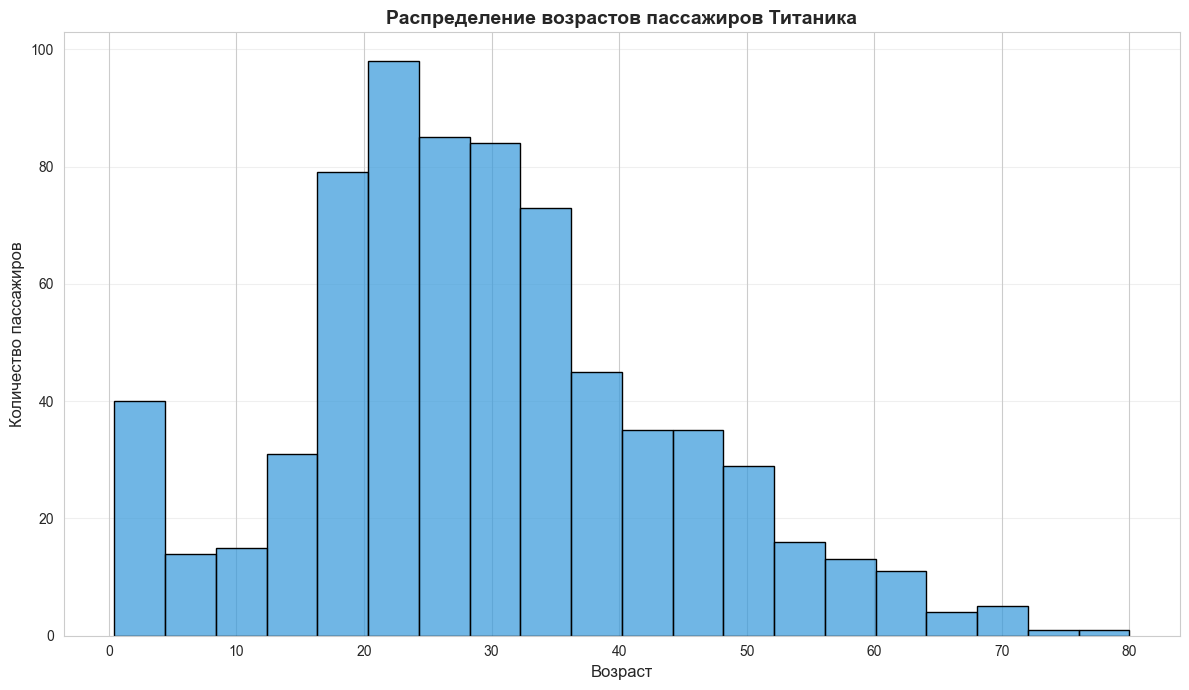

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.figure(figsize=(12, 7))
sns.histplot(df["Age"].dropna(), bins=20, color="#3498db", edgecolor="black", alpha=0.7)

plt.xlabel("Возраст", fontsize=12)
plt.ylabel("Количество пассажиров", fontsize=12)
plt.title("Распределение возрастов пассажиров Титаника", fontsize=14, fontweight="bold")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

2. Постройте гистограммы распределения цен для пассажиров разных классов

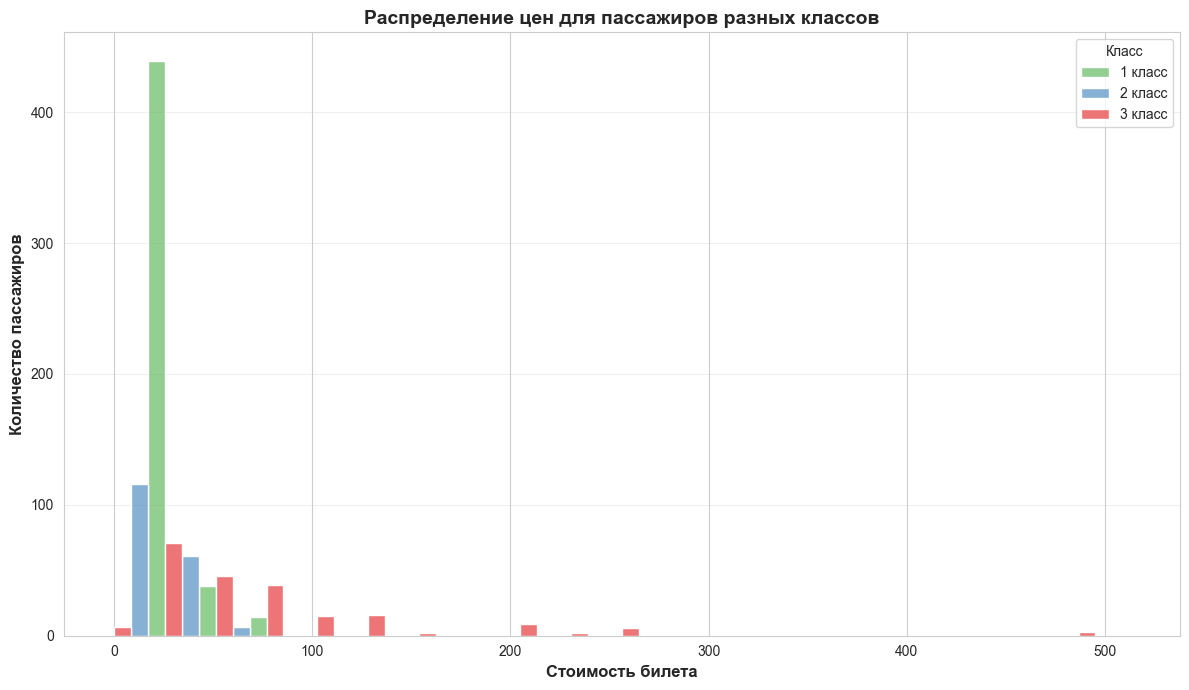

In [26]:
sns.set_style("whitegrid")
plt.figure(figsize=(12, 7))

sns.histplot(data=df, x="Fare", hue="Pclass", bins=20,
             palette="Set1", alpha=0.6, edgecolor="white",
             multiple="dodge")

plt.xlabel("Стоимость билета", fontsize=12, fontweight="bold")
plt.ylabel("Количество пассажиров", fontsize=12, fontweight="bold")
plt.title("Распределение цен для пассажиров разных классов",
          fontsize=14, fontweight="bold")
plt.legend(title="Класс", labels=["1 класс", "2 класс", "3 класс"])
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

3. Постройте зависимость цены от возраста пассажира

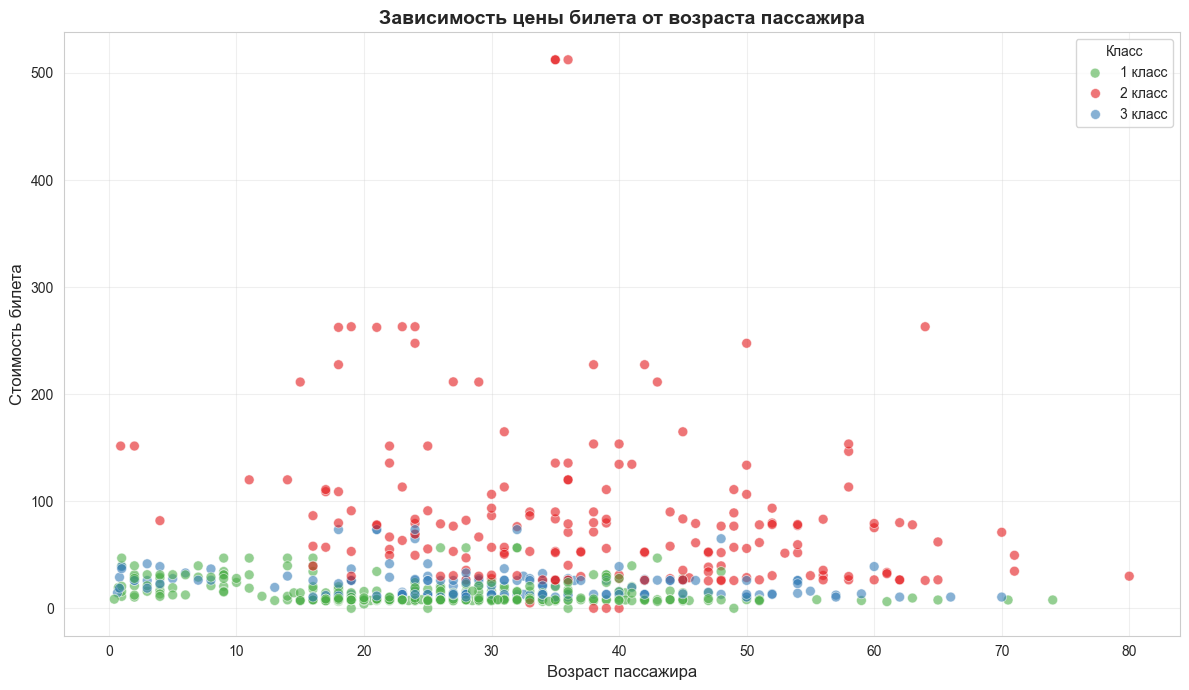

In [27]:

sns.set_style("whitegrid")
plt.figure(figsize=(12, 7))

sns.scatterplot(data=df, x="Age", y="Fare", hue="Pclass",
                palette="Set1", alpha=0.6, s=50)

plt.xlabel("Возраст пассажира", fontsize=12)
plt.ylabel("Стоимость билета", fontsize=12)
plt.title("Зависимость цены билета от возраста пассажира",
          fontsize=14, fontweight="bold")
plt.legend(title="Класс", labels=["1 класс", "2 класс", "3 класс"])
plt.grid(axis="both", alpha=0.3)

plt.tight_layout()
plt.show()

4. Постройте box plot отображающий распределение цен на билеты в разных классах

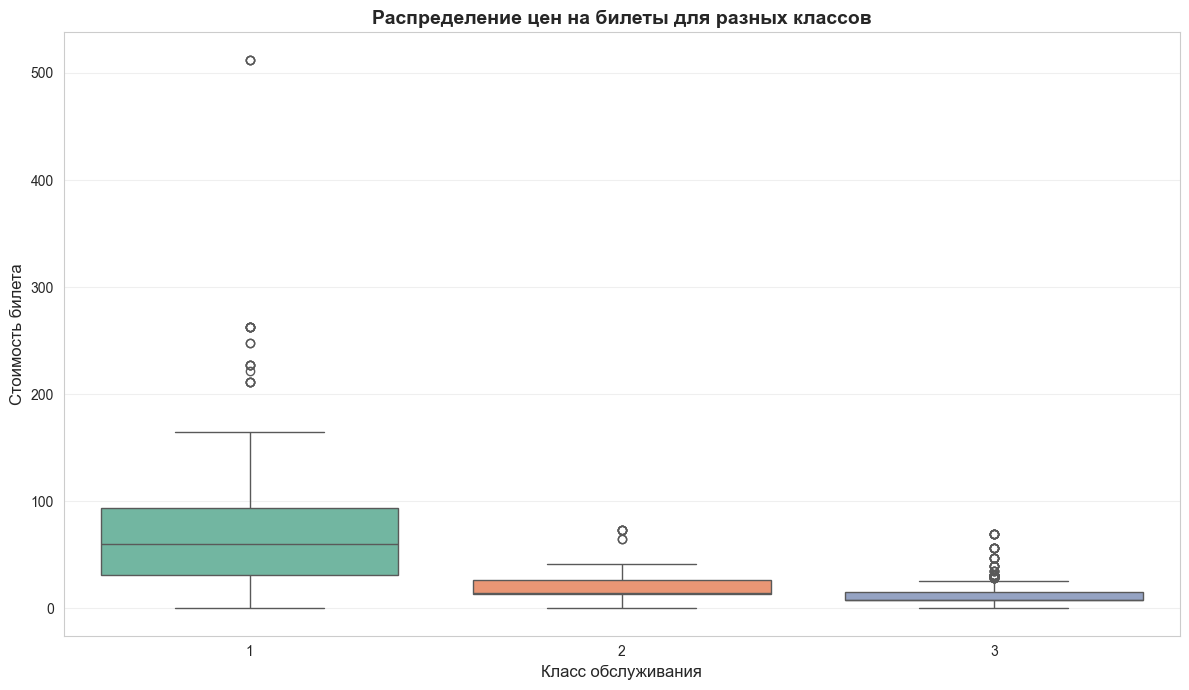

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.figure(figsize=(12, 7))

sns.boxplot(data=df, x="Pclass", y="Fare",
            hue="Pclass", palette="Set2", legend=False)

plt.xlabel("Класс обслуживания", fontsize=12)
plt.ylabel("Стоимость билета", fontsize=12)
plt.title("Распределение цен на билеты для разных классов",
          fontsize=14, fontweight="bold")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

5. Визуализируйте распределение долей выживших среди мужчин, женщин и детей(до 16 лет)

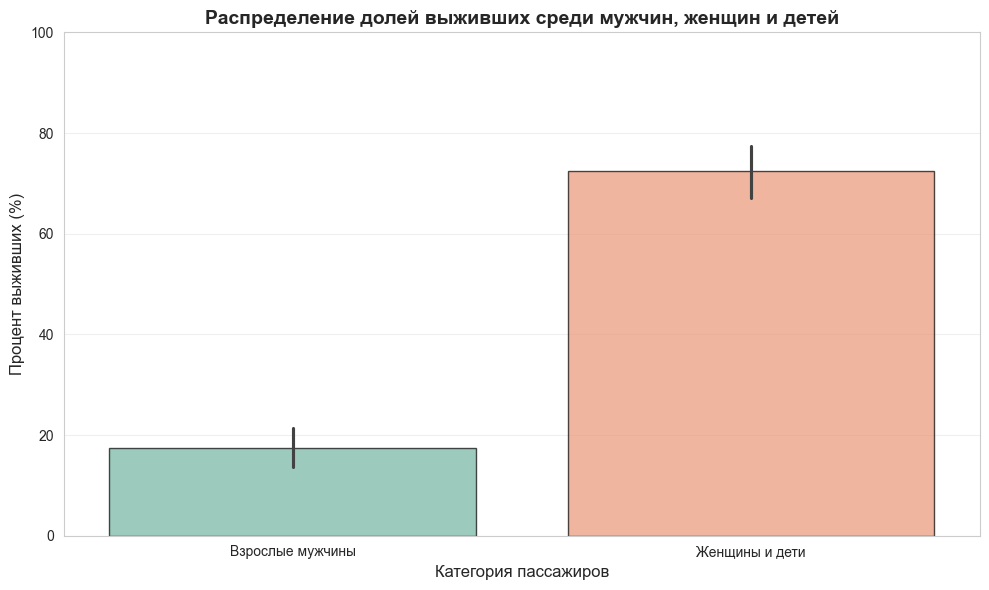

In [29]:
# df_age из 2.4
sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))

sns.barplot(data=df_age, x="Category", y="Survived", hue="Category", legend=False,
            palette="Set2", edgecolor="black", alpha=0.7,
            estimator=lambda x: sum(x) / len(x) * 100)

plt.xlabel("Категория пассажиров", fontsize=12)
plt.ylabel("Процент выживших (%)", fontsize=12)
plt.title("Распределение долей выживших среди мужчин, женщин и детей",
          fontsize=14, fontweight="bold")
plt.ylim(0, 100)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

6. Сравните плотности распределения возростов выживших и умерших пассажиров, сделайте выводы

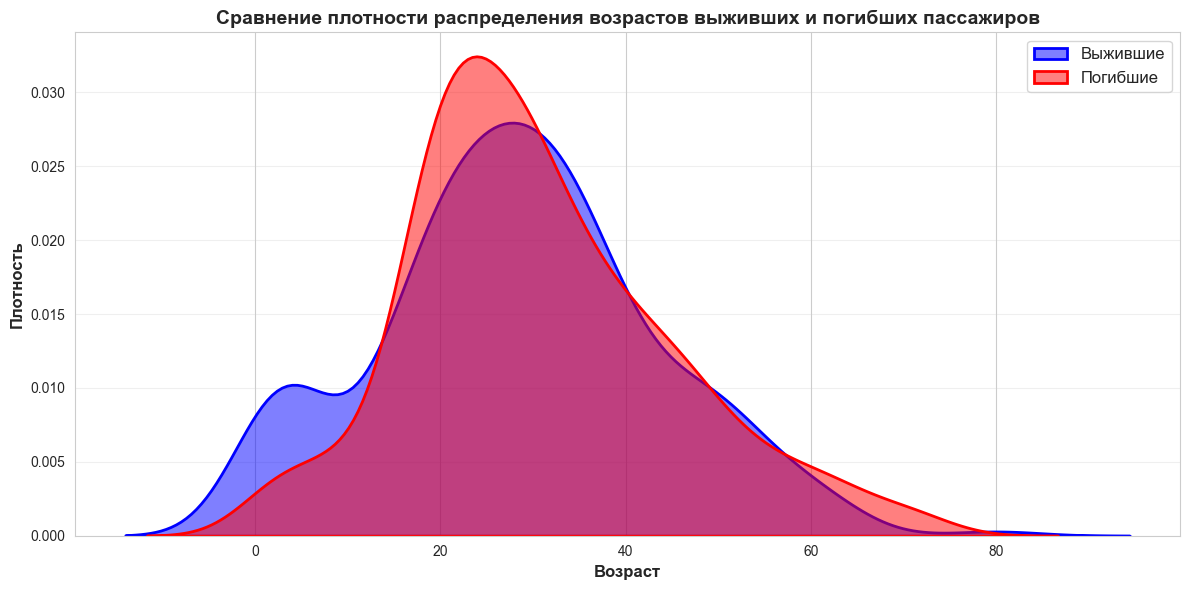

СТАТИСТИКА:
--------------------------------------------------
Средний возраст выживших: 28.3 лет
Средний возраст погибших: 30.6 лет

Медианный возраст выживших: 28.0 лет
Медианный возраст погибших: 28.0 лет


In [30]:
sns.set_style("whitegrid")
plt.figure(figsize=(12, 6))

survived = df[df["Survived"] == 1]["Age"].dropna()
died = df[df["Survived"] == 0]["Age"].dropna()

sns.kdeplot(survived, label="Выжившие", color="blue",
            fill=True, alpha=0.5, linewidth=2)
sns.kdeplot(died, label="Погибшие", color="red",
            fill=True, alpha=0.5, linewidth=2)

plt.xlabel("Возраст", fontsize=12, fontweight="bold")
plt.ylabel("Плотность", fontsize=12, fontweight="bold")
plt.title("Сравнение плотности распределения возрастов выживших и погибших пассажиров",
          fontsize=14, fontweight="bold")
plt.legend(fontsize=12)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

print("СТАТИСТИКА:")
print("-" * 50)
print(f"Средний возраст выживших: {survived.mean():.1f} лет")
print(f"Средний возраст погибших: {died.mean():.1f} лет")
print(f"\nМедианный возраст выживших: {survived.median():.1f} лет")
print(f"Медианный возраст погибших: {died.median():.1f} лет")

7. Постройте круговую диаграмму отображающую выживаемость мужчин и женщин в разных классах обслуживания(визуализация должна быть интуитивно понятная без объяснений, женщины и мужчины соответствующих классов объеденены визуально в одну группу и 2 подгруппы)*

\* Задание на доп. балл

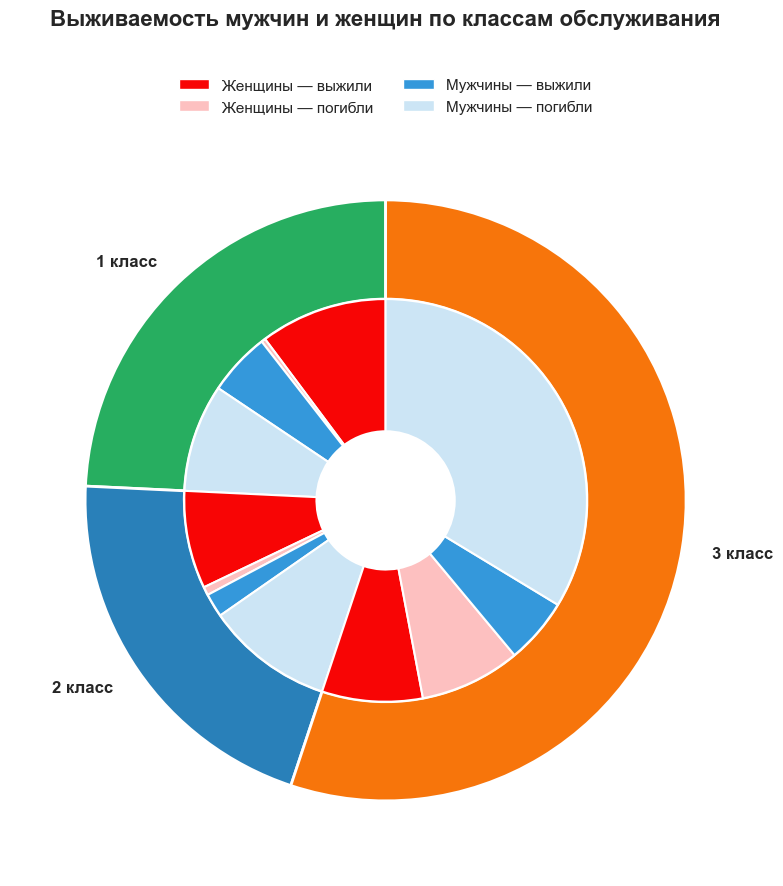

In [31]:

agg = (df.groupby(["Pclass", "Sex", "Survived"])
       .size().reset_index(name="Count"))

sex_name = {"female": "Женщины", "male": "Мужчины"}
class_labels = {1: "1 класс", 2: "2 класс", 3: "3 класс"}
sex_colors = {"female": "#f80505", "male": "#3498db"}
dead_alpha = 0.25

outer_sizes = [agg[agg["Pclass"] == c]["Count"].sum() for c in [1, 2, 3]]
outer_labels = [class_labels[c] for c in [1, 2, 3]]
outer_colors = ["#27ae60", "#2980b9", "#f7750b"]

inner_sizes, inner_colors, inner_labels = [], [], []
for c in [1, 2, 3]:
    sub = agg[agg["Pclass"] == c]
    for sex in ["female", "male"]:
        surv = sub[(sub["Sex"] == sex) & (sub["Survived"] == 1)]["Count"].sum()
        dead = sub[(sub["Sex"] == sex) & (sub["Survived"] == 0)]["Count"].sum()

        if surv > 0:
            inner_sizes.append(surv)
            inner_colors.append(sex_colors[sex])
            inner_labels.append("")

        if dead > 0:
            base = np.array(plt.matplotlib.colors.to_rgb(sex_colors[sex]))
            inner_colors.append((*base, dead_alpha))
            inner_sizes.append(dead)
            inner_labels.append("")

fig, ax = plt.subplots(figsize=(12, 9), subplot_kw=dict(aspect="equal"))
fig.patch.set_facecolor("white")

plt.suptitle("Выживаемость мужчин и женщин по классам обслуживания",
             fontsize=16, fontweight="bold", y=0.98)

ax.pie(outer_sizes, labels=outer_labels, colors=outer_colors,
       radius=1.0, startangle=90,
       wedgeprops=dict(width=0.33, edgecolor="white", linewidth=2),
       textprops={"fontsize": 12, "fontweight": "bold"})

ax.pie(inner_sizes, labels=inner_labels, colors=inner_colors,
       radius=0.67, startangle=90,
       wedgeprops=dict(width=0.44, edgecolor="white", linewidth=1.5))

from matplotlib.patches import Patch

legend_items = [
    Patch(facecolor=sex_colors["female"], edgecolor="white", label="Женщины — выжили"),
    Patch(facecolor=(*plt.matplotlib.colors.to_rgb(sex_colors["female"]), dead_alpha),
          edgecolor="white", label="Женщины — погибли"),
    Patch(facecolor=sex_colors["male"], edgecolor="white", label="Мужчины — выжили"),
    Patch(facecolor=(*plt.matplotlib.colors.to_rgb(sex_colors["male"]), dead_alpha),
          edgecolor="white", label="Мужчины — погибли"),
]
leg = ax.legend(handles=legend_items, loc="upper center", ncol=2,
                bbox_to_anchor=(0.5, 1.08), frameon=False, fontsize=11)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()
